In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

duckdb_dir = "bench_duckdb_20260329_023211"
pandas_dir = "bench_pandas_20260329_023225"

In [3]:
def load_run(path):
    ps = pd.read_csv(f"{path}/ps.csv")
    app = pd.read_csv(f"{path}/app.csv")
    return ps, app

ps_duck, app_duck = load_run(duckdb_dir)
ps_pandas, app_pandas = load_run(pandas_dir)

In [4]:
def process_ps(df):
    df = df.copy()

    # convert timestamp → datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S.%f")

    # normalize to start at 0 ms
    t0 = df["timestamp"].min()
    df["time_ms"] = (df["timestamp"] - t0).dt.total_seconds() * 1000

    return df

ps_duck = process_ps(ps_duck)
ps_pandas = process_ps(ps_pandas)

In [5]:
def aggregate_ps(df):
    agg = df.groupby("time_ms").agg({
        "cpu_percent": "sum",
        "rss_kb": "sum"
    }).reset_index()

    return agg

agg_duck = aggregate_ps(ps_duck)
agg_pandas = aggregate_ps(ps_pandas)

In [6]:
def process_app(df):
    df = df.copy()

    df["time_ms"] = df["time_s"] * 1000

    # throughput = delta count / delta time
    df["throughput"] = df["total_count"].diff() / df["time_s"].diff()

    df = df.fillna(0)

    return df

app_duck = process_app(app_duck)
app_pandas = process_app(app_pandas)

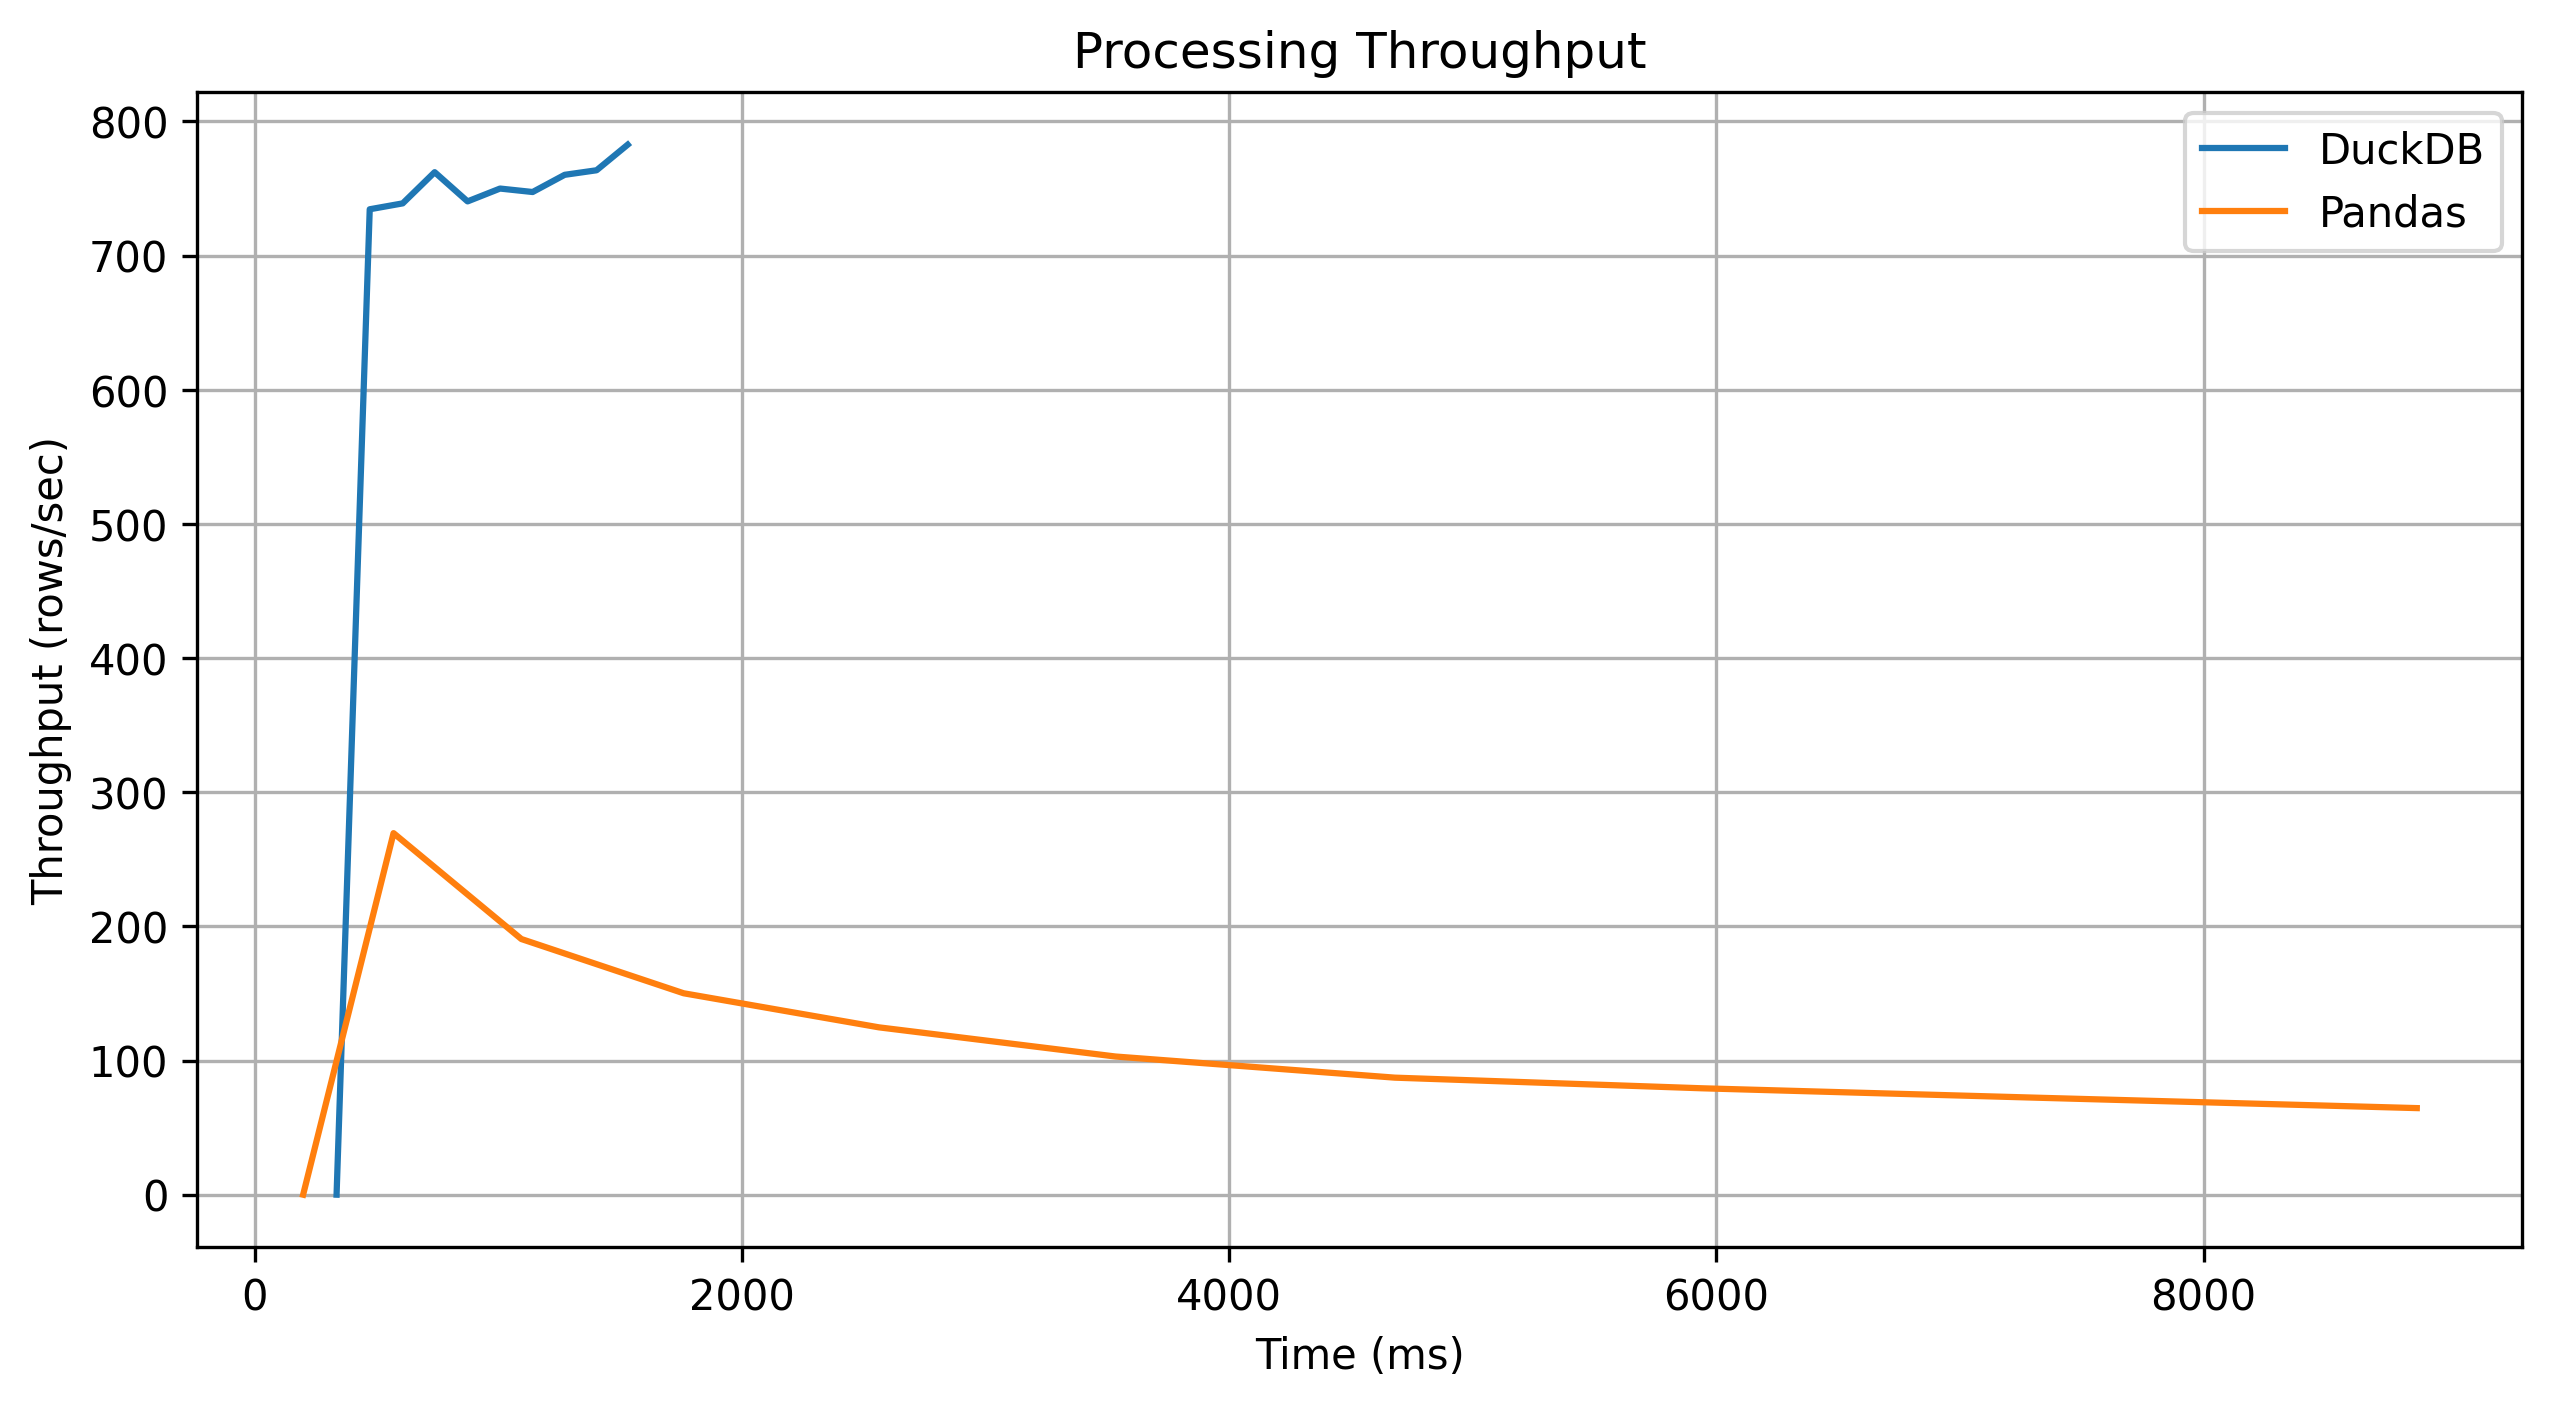

In [7]:
plt.figure(figsize=(10, 5), dpi=300)

plt.plot(app_duck["time_ms"], app_duck["throughput"], label="DuckDB")
plt.plot(app_pandas["time_ms"], app_pandas["throughput"], label="Pandas")

plt.xlabel("Time (ms)")
plt.ylabel("Throughput (rows/sec)")
plt.title("Processing Throughput")
plt.legend()
plt.grid()

plt.show()

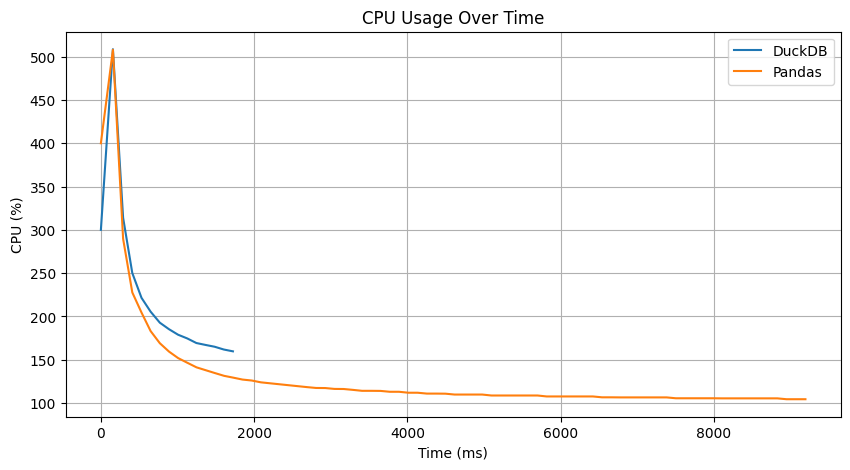

In [ ]:
plt.figure(figsize=(10, 5), dpi=300)

plt.plot(agg_duck["time_ms"], agg_duck["cpu_percent"], label="DuckDB")
plt.plot(agg_pandas["time_ms"], agg_pandas["cpu_percent"], label="Pandas")

plt.xlabel("Time (ms)")
plt.ylabel("CPU (%)")
plt.title("CPU Usage Over Time")
plt.legend()
plt.grid()

plt.show()

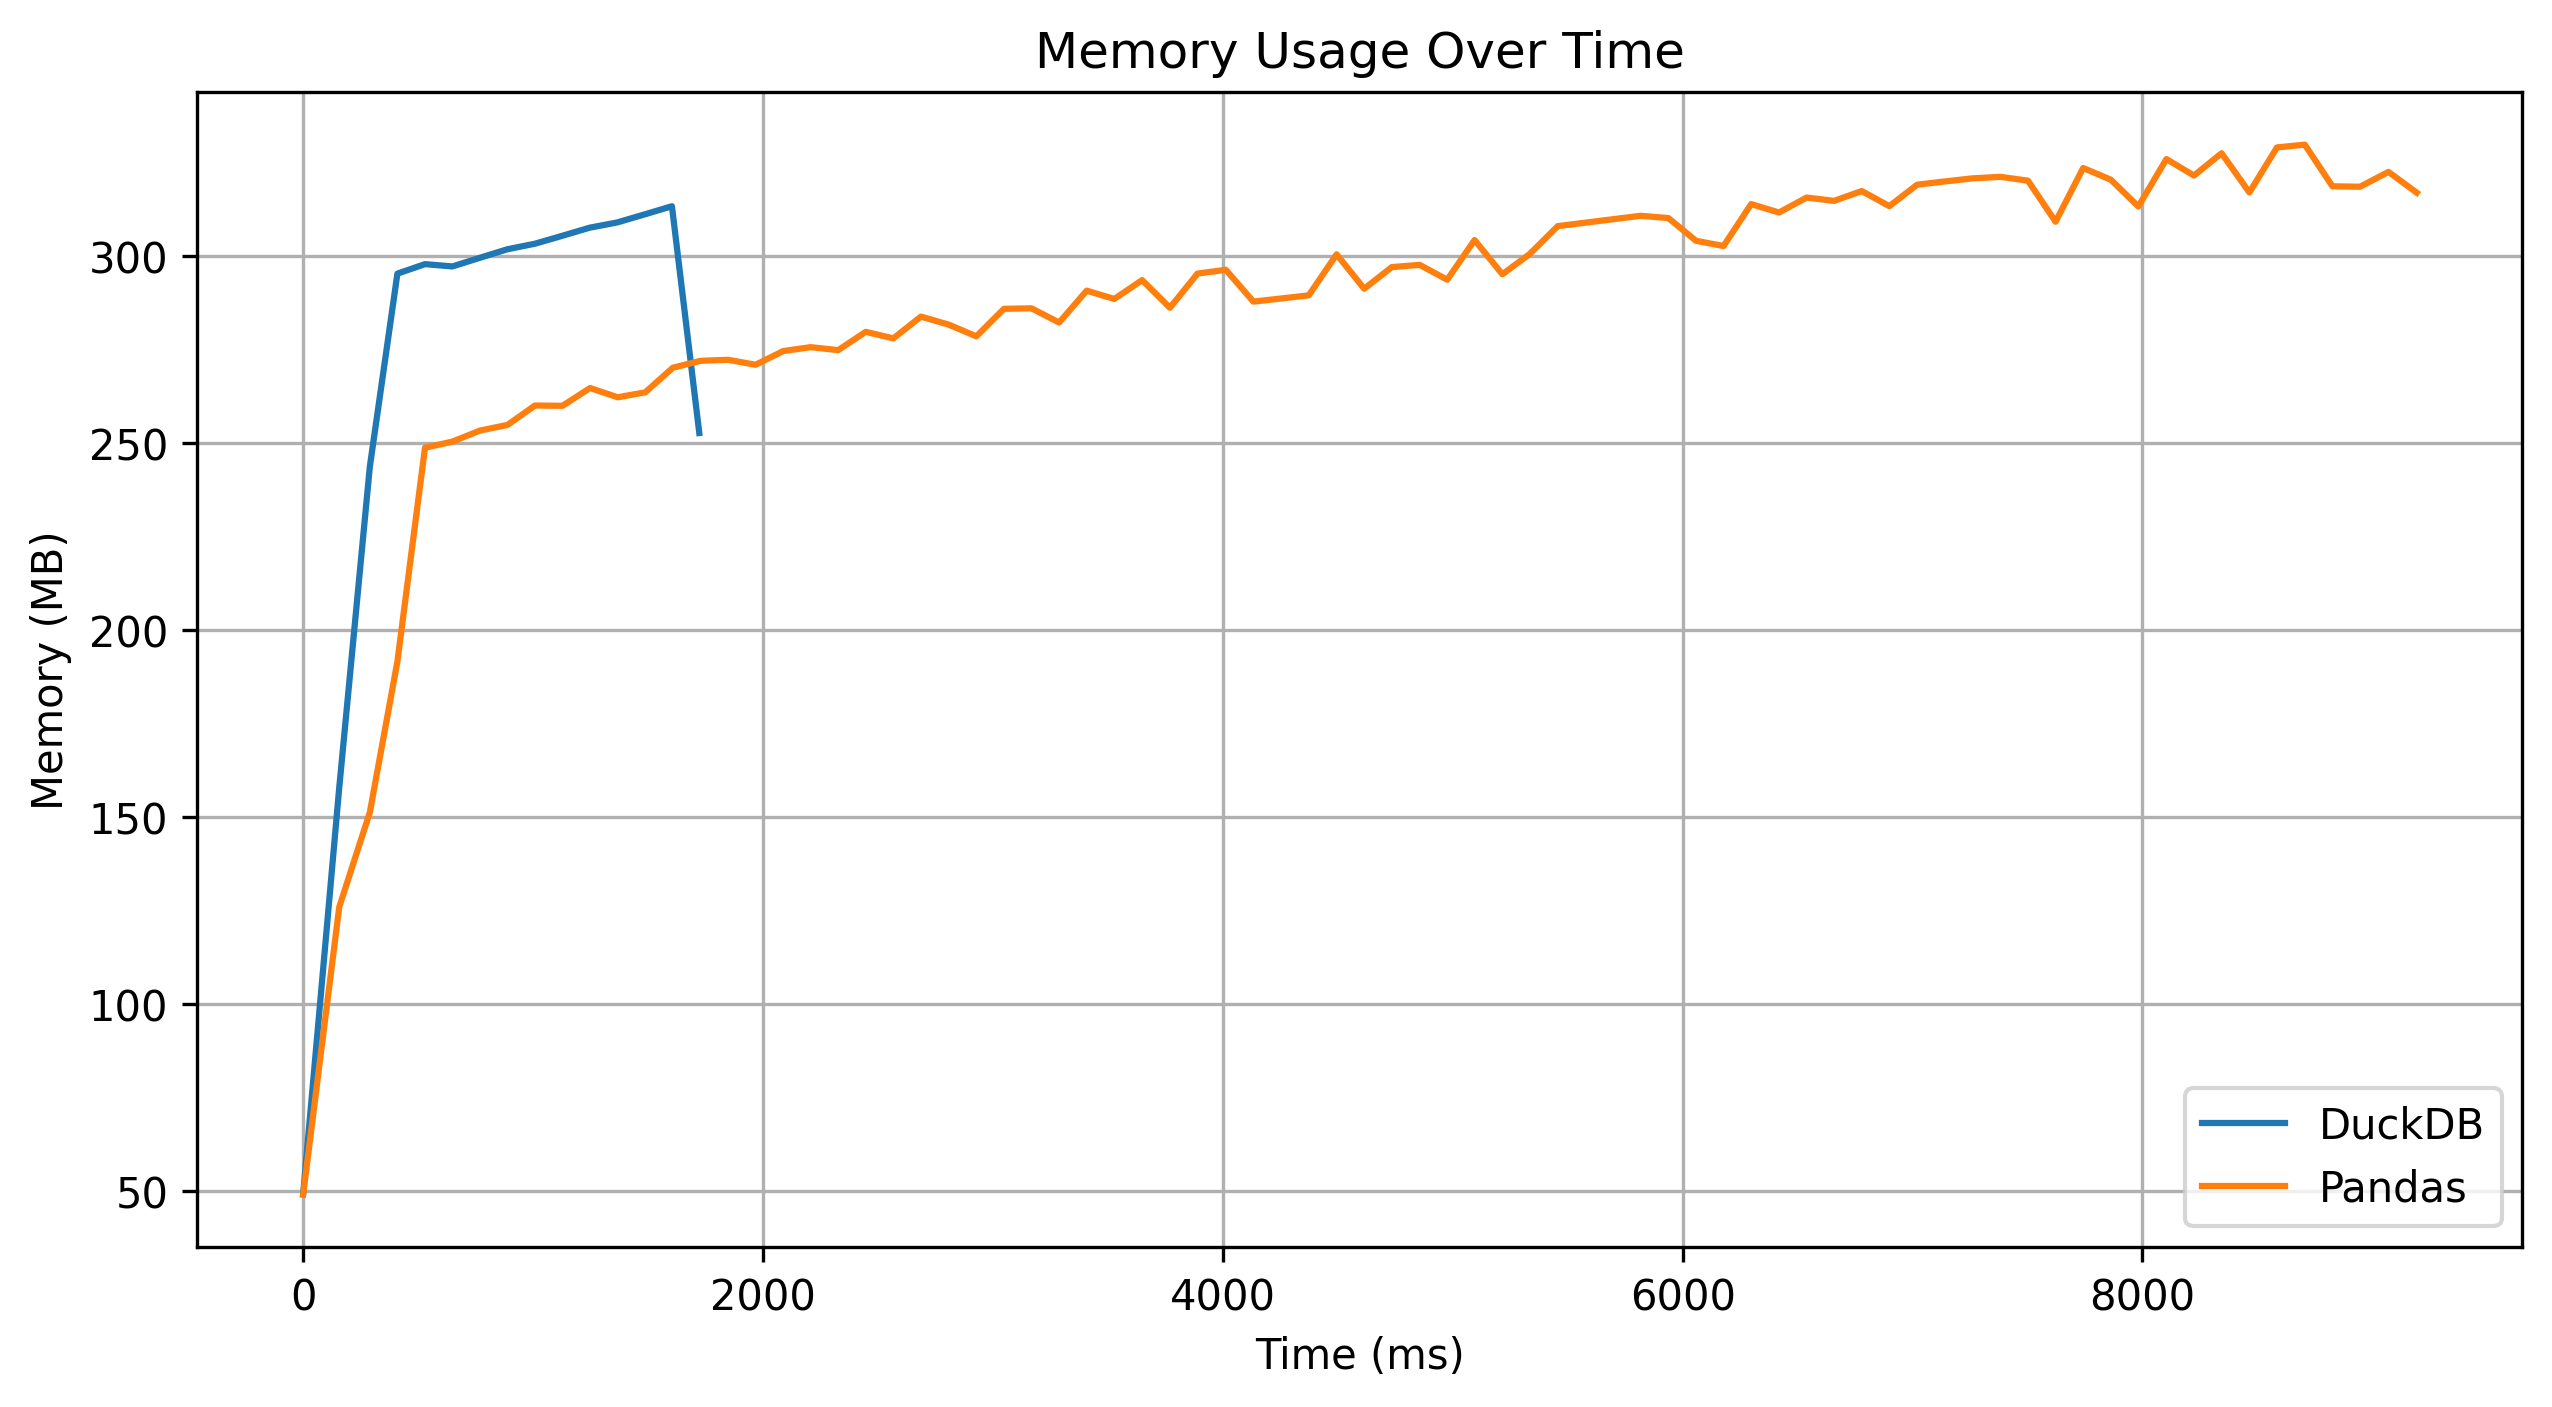

In [17]:
plt.figure(figsize=(10, 5), dpi=300)

plt.plot(agg_duck["time_ms"], agg_duck["rss_kb"] / 1024, label="DuckDB")
plt.plot(agg_pandas["time_ms"], agg_pandas["rss_kb"] / 1024, label="Pandas")

plt.xlabel("Time (ms)")
plt.ylabel("Memory (MB)")
plt.title("Memory Usage Over Time")
plt.legend()
plt.grid()

plt.show()